In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math

In [2]:
# 1
# Import the data from medical_examination.csv and assign it to the df variable.
df = pd.read_csv('medical_examination.csv')
len(df)
df.columns
df.head()
df.shape

(70000, 13)

In [3]:
# 2
# Add an overweight column to the data. To determine if a person is overweight, 
# first calculate their BMI by dividing their weight in kilograms by the square of their height in meters.
# If that value is > 25 then the person is overweight. Use the value 0 for NOT overweight and the value 1 for overweight.
df['overweight'] = df['weight'] / (df['height']/100)**2 >25
df.head()
df.shape

(70000, 14)

In [4]:
# df['overweight'].value_counts()
df['overweight'] = df['overweight'].astype(int) 
df.head()

,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,overweight
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,0
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,0


In [5]:
# 3
# Normalize data by making 0 always good and 1 always bad.
# If the value of cholesterol or gluc is 1, set the value to 0. If the value is more than 1, set the value to 1.
# 1 >> 0  ||  +1 >> 1
columns = ['cholesterol', 'gluc']
for col in columns:
    print(df[col].value_counts())
    df[col] = df[col].replace({1: 0, 2: 1, 3: 1})
    print(df[col].value_counts())
df.head()

# df.shape

cholesterol
1    52385
2     9549
3     8066
Name: count, dtype: int64
cholesterol
0    52385
1    17615
Name: count, dtype: int64
gluc
1    59479
3     5331
2     5190
Name: count, dtype: int64
gluc
0    59479
1    10521
Name: count, dtype: int64


,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,overweight
0,0,18393,2,168,62.0,110,80,0,0,0,0,1,0,0
1,1,20228,1,156,85.0,140,90,1,0,0,0,1,1,1
2,2,18857,1,165,64.0,130,70,1,0,0,0,0,1,0
3,3,17623,2,169,82.0,150,100,0,0,0,0,1,1,1
4,4,17474,1,156,56.0,100,60,0,0,0,0,0,0,0


In [6]:
 # 5
# Create a DataFrame for the cat plot using pd.melt with values from cholesterol, gluc, smoke, alco, active, and overweight in the df_cat variable.
df_cat = pd.melt(df,id_vars=['id', 'age', 'sex', 'height', 'weight', 'cardio'], value_vars=['cholesterol', 'gluc', 'smoke', 'alco', 'active', 'overweight'] )
df_cat.head(5)
# df_cat['variable']
# df_cat.shape

,id,age,sex,height,weight,cardio,variable,value
0,0,18393,2,168,62.0,0,cholesterol,0
1,1,20228,1,156,85.0,1,cholesterol,1
2,2,18857,1,165,64.0,1,cholesterol,1
3,3,17623,2,169,82.0,1,cholesterol,0
4,4,17474,1,156,56.0,0,cholesterol,0


In [7]:
 # 6
# Group and reformat the data in df_cat to split it by cardio. Show the counts of each feature. You will have to rename one of the columns for the catplot to work correctly.

# df_cat = df_cat.groupby('cardio')
# df_cat1 = df_cat.count()
# df_cat1.head()
# # df_cat.shape

df_cat_counts = df_cat.groupby(['cardio', 'variable', 'value']).size().reset_index(name='count')
# df_cat_counts.value_counts()
df_cat_counts

,cardio,variable,value,count
0,0,active,0,6378
1,0,active,1,28643
2,0,alco,0,33080
3,0,alco,1,1941
4,0,cholesterol,0,29330
5,0,cholesterol,1,5691
6,0,gluc,0,30894
7,0,gluc,1,4127
8,0,overweight,0,15915
9,0,overweight,1,19106


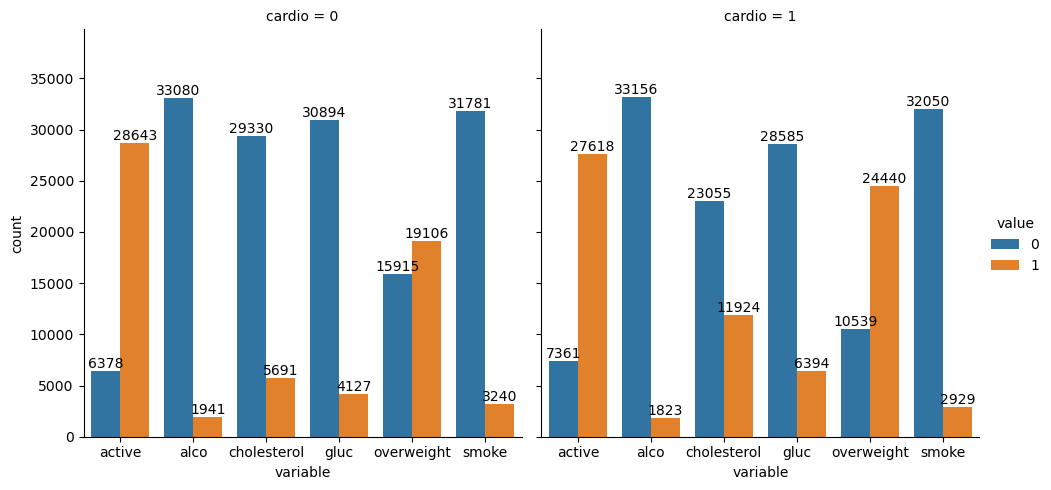

In [47]:
# 7
# Convert the data into long format and create a chart that shows the value counts of the categorical features using
# the following method provided by the seaborn library import: sns.catplot().

# sns.catplot(data=df_cat)
g = sns.catplot(data=df_cat_counts, x='variable', y='count' ,col='cardio', hue='value', legend=True, kind='bar')
# iterate through axes
for ax in g.axes.ravel():
    # add annotations
    for c in ax.containers:
        labels = [f'{(v.get_height() ):.0f}' for v in c]
        ax.bar_label(c, labels=labels, label_type='edge')
    ax.margins(y=0.2)

# plt.show()

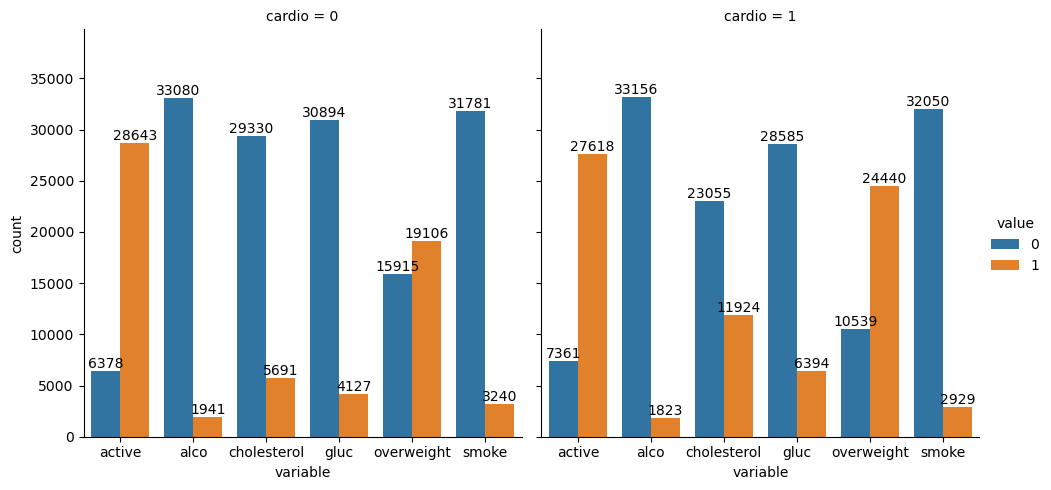

In [9]:
# 8
# Get the figure for the output and store it in the fig variable.
fig = ax.get_figure()
fig

In [50]:
# 4
# Draw the Categorical Plot in the draw_cat_plot function.
def draw_cat_plot():
    
    # 5
# Create a DataFrame for the cat plot using pd.melt with values from cholesterol, gluc, smoke, alco, active, and overweight in the df_cat variable.
    df_cat = pd.melt(df,id_vars=['id', 'age', 'sex', 'height', 'weight', 'cardio'], value_vars=['cholesterol', 'gluc', 'smoke', 'alco', 'active', 'overweight'] )

    # 6
    # Group and reformat the data in df_cat to split it by cardio. Show the counts of each feature. You will have to rename one of the columns for the catplot to work correctly.

    df_cat = df_cat.groupby(['cardio', 'variable', 'value']).size().reset_index(name='count')
    
    # 7
# Convert the data into long format and create a chart that shows the value counts of the categorical features using the following method provided by the seaborn library import: sns.catplot().
    g = sns.catplot(data=df_cat, x='variable', y='count' ,col='cardio', hue='value', legend=True, kind='bar')
    
    # Set the correct axis labels that the tests expect
    g.set_axis_labels("variable", "total")
    
    # iterate through axes
    for ax in g.axes.ravel():
        # add annotations
        for c in ax.containers:
            labels = [f'{(v.get_height() ):.0f}' for v in c]
            ax.bar_label(c, labels=labels, label_type='edge')
        ax.margins(y=0.2)


    # 8
#     Get the figure for the output and store it in the fig variable.
    fig = g.fig


    # 9
#     Do not modify the next two lines.
    fig.savefig('catplot.png')
    return fig

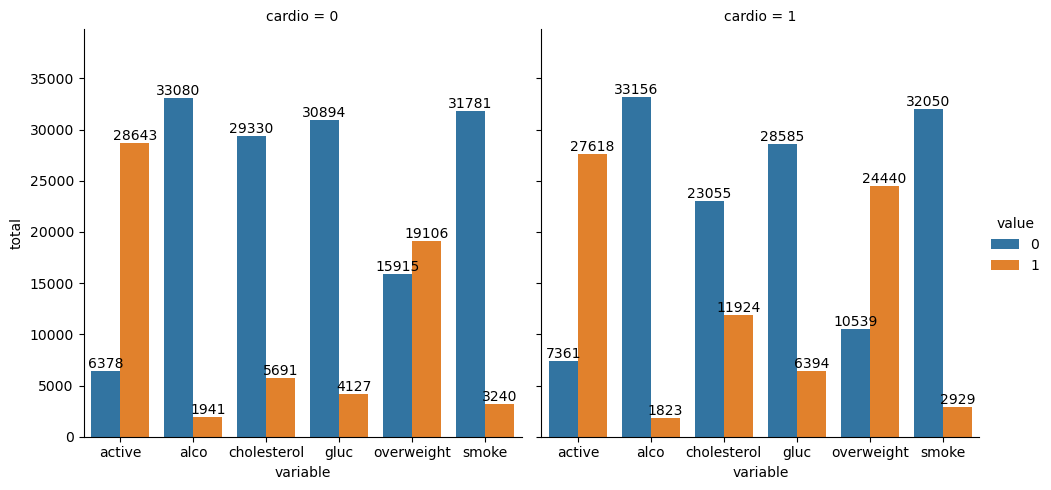

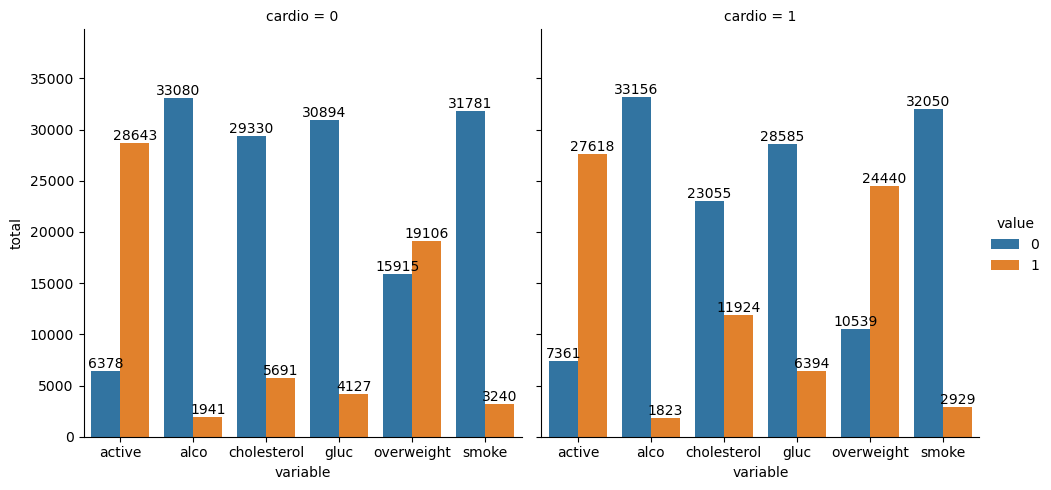

In [51]:
draw_cat_plot()

In [10]:
# 10
# Draw the Heat Map in the draw_heat_map function.
df.head()
# df.shape // ((70000, 14))

# 11
# Clean the data in the df_heat variable by filtering out the following patient segments that represent incorrect data:
# diastolic pressure is higher than systolic (Keep the correct data with (df['ap_lo'] <= df['ap_hi']))
df_heat = df.loc[(df['ap_lo'] <= df['ap_hi'])]
# df_heat.shape // (68766, 14)
# df_heat.head()
# height is less than the 2.5th percentile (Keep the correct data with (df['height'] >= df['height'].quantile(0.025)))
df_heat = df.loc[(df['ap_lo'] <= df['ap_hi']) &
                 (df['height'] >= df['height'].quantile(0.025))]
# df_heat.shape // (67260, 14)
df_heat.head()
# height is more than the 97.5th percentile
df_heat = df.loc[(df['ap_lo'] <= df['ap_hi']) &
                 (df['height'] >= df['height'].quantile(0.025)) &
                 (df['height'] <= df['height'].quantile(0.975) )]
# df_heat.shape // (65859, 14) 
# weight is less than the 2.5th percentile
df_heat = df.loc[(df['ap_lo'] <= df['ap_hi']) &
                 (df['height'] >= df['height'].quantile(0.025)) &
                 (df['height'] <= df['height'].quantile(0.975) ) &
                 (df['weight'] >= df['weight'].quantile(0.025))]
# df_heat.shape // (64623, 14)
# # weight is more than the 97.5th percentile 
df_heat = df.loc[(df['ap_lo'] <= df['ap_hi']) & 
                 (df['height'] >= df['height'].quantile(0.025)) & 
                 (df['height'] <= df['height'].quantile(0.975)) & 
                 (df['weight'] >= df['weight'].quantile(0.025)) & 
                 (df['weight'] <= df['weight'].quantile(0.975))]
df_heat.shape 
# //(63259, 14)

(63259, 14)

In [13]:
 # 12
#     Calculate the correlation matrix and store it in the corr variable.
corr = df_heat.corr()
corr


,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,overweight
id,1.000000,0.002507,0.003426,0.000326,0.000149,0.003492,0.000484,0.003719,0.002289,-0.002732,-0.000708,0.005891,0.003900,-0.000679
age,0.002507,1.000000,-0.018132,-0.076932,0.070168,0.018689,0.153508,0.129996,0.086990,-0.044371,-0.026970,-0.011445,0.240241,0.089573
sex,0.003426,-0.018132,1.000000,0.505785,0.129979,0.005063,0.059947,-0.037605,-0.021357,0.337436,0.168637,0.007864,0.002320,-0.052930
height,0.000326,-0.076932,0.505785,1.000000,0.251503,0.004586,0.017922,-0.063522,-0.030469,0.187830,0.089785,-0.005661,-0.024102,-0.149570
weight,0.000149,0.070168,0.129979,0.251503,1.000000,0.027030,0.227922,0.135981,0.107072,0.056533,0.059917,-0.014430,0.170042,0.655926
ap_hi,0.003492,0.018689,0.005063,0.004586,0.027030,1.000000,0.072803,0.022807,0.011111,-0.001928,0.000769,-0.000222,0.050556,0.017327
ap_lo,0.000484,0.153508,0.059947,0.017922,0.227922,0.072803,1.000000,0.150362,0.074840,0.023275,0.033042,0.001569,0.327181,0.172212
cholesterol,0.003719,0.129996,-0.037605,-0.063522,0.135981,0.022807,0.150362,1.000000,0.383743,0.012680,0.038446,0.002494,0.203467,0.127986
gluc,0.002289,0.086990,-0.021357,-0.030469,0.107072,0.011111,0.074840,0.383743,1.000000,-0.004157,0.014297,-0.010145,0.088445,0.088109
smoke,-0.002732,-0.044371,0.337436,0.187830,0.056533,-0.001928,0.023275,0.012680,-0.004157,1.000000,0.341200,0.026940,-0.020345,-0.003274


In [21]:
    # 13
#     Generate a mask for the upper triangle and store it in the mask variable.
mask = np.triu(corr)
mask

array([[ 1.00000000e+00,  2.50729691e-03,  3.42610273e-03,
         3.25916709e-04,  1.49333224e-04,  3.49238023e-03,
         4.83670793e-04,  3.71939143e-03,  2.28909034e-03,
        -2.73227725e-03, -7.08059804e-04,  5.89114223e-03,
         3.90011059e-03, -6.79420314e-04],
       [ 0.00000000e+00,  1.00000000e+00, -1.81320052e-02,
        -7.69318347e-02,  7.01683896e-02,  1.86894095e-02,
         1.53507973e-01,  1.29996176e-01,  8.69901449e-02,
        -4.43706471e-02, -2.69695382e-02, -1.14451266e-02,
         2.40241089e-01,  8.95726547e-02],
       [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00,
         5.05784851e-01,  1.29979320e-01,  5.06250408e-03,
         5.99466484e-02, -3.76050443e-02, -2.13573847e-02,
         3.37435881e-01,  1.68637124e-01,  7.86370242e-03,
         2.31999158e-03, -5.29296848e-02],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00,  2.51502865e-01,  4.58573625e-03,
         1.79224331e-02, -6.35217890e-02, -3.

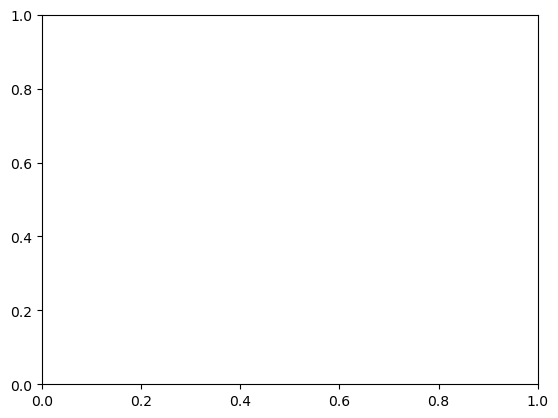

In [27]:
 # 14
# Set up the matplotlib figure.
fig, ax = plt.subplots()


<AxesSubplot:>

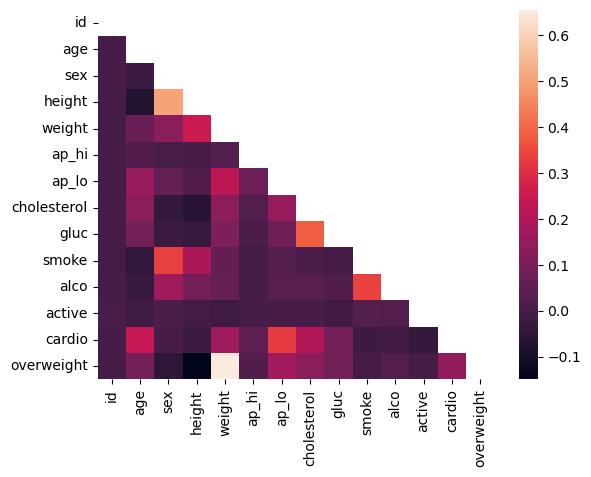

In [33]:
    # 15
# Plot the correlation matrix using the method provided by the seaborn library import: sns.heatmap().
fig = sns.heatmap(data=corr, mask=mask)
fig

In [48]:
# 10
# Draw the Heat Map in the draw_heat_map function.
def draw_heat_map():
    # 11
#     Clean the data in the df_heat variable by filtering out the following patient segments that represent incorrect data:
#     diastolic pressure is higher than systolic (Keep the correct data with (df['ap_lo'] <= df['ap_hi']))
#     height is less than the 2.5th percentile (Keep the correct data with (df['height'] >= df['height'].quantile(0.025)))
#     height is more than the 97.5th percentile
#     weight is less than the 2.5th percentile
#     weight is more than the 97.5th percentile

    df_heat = df.loc[(df['ap_lo'] <= df['ap_hi']) & 
                (df['height'] >= df['height'].quantile(0.025)) & 
                (df['height'] <= df['height'].quantile(0.975)) & 
                (df['weight'] >= df['weight'].quantile(0.025)) & 
                (df['weight'] <= df['weight'].quantile(0.975))] 

    # 12
#     Calculate the correlation matrix and store it in the corr variable.
    corr = df_heat.corr() # type: ignore

    # 13
#     Generate a mask for the upper triangle and store it in the mask variable.
    mask = np.triu(corr)



    # 14
#     Set up the matplotlib figure.
    fig, ax =  plt.subplots(figsize=(12, 9))

    # 15
#     Plot the correlation matrix using the method provided by the seaborn library import: sns.heatmap().
    sns.heatmap(data=corr, mask=mask, annot=True, fmt='.1f', ax=ax, square=True, linewidths=0.5, cbar_kws={"shrink": .8})


    # 16
#     Do not modify the next two lines.
    fig.savefig('heatmap.png')
    return fig

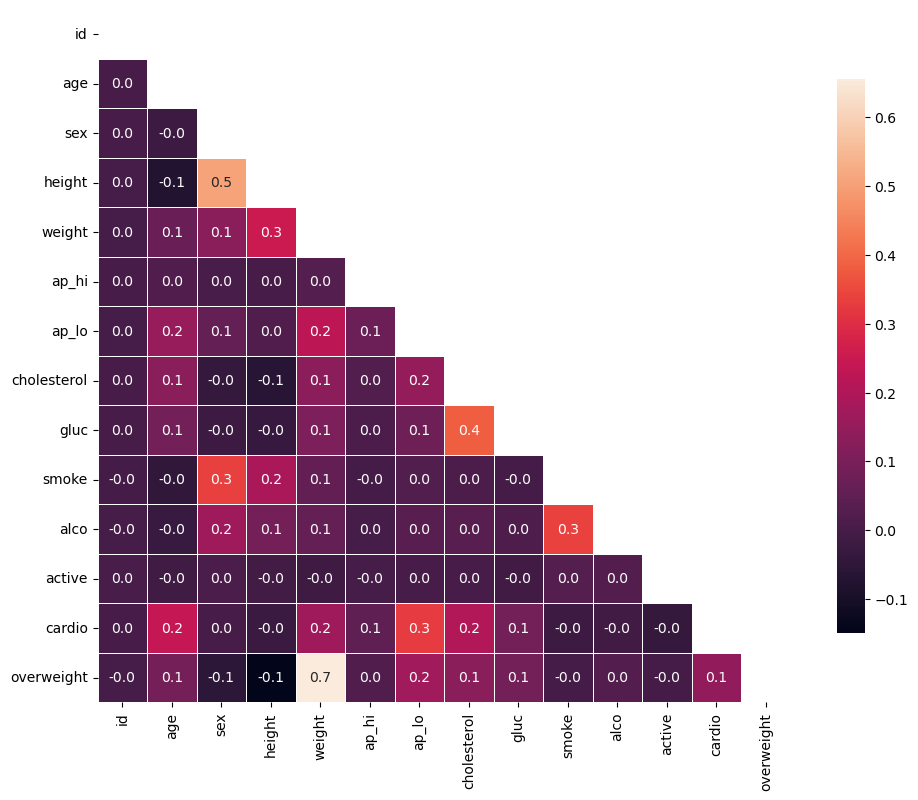

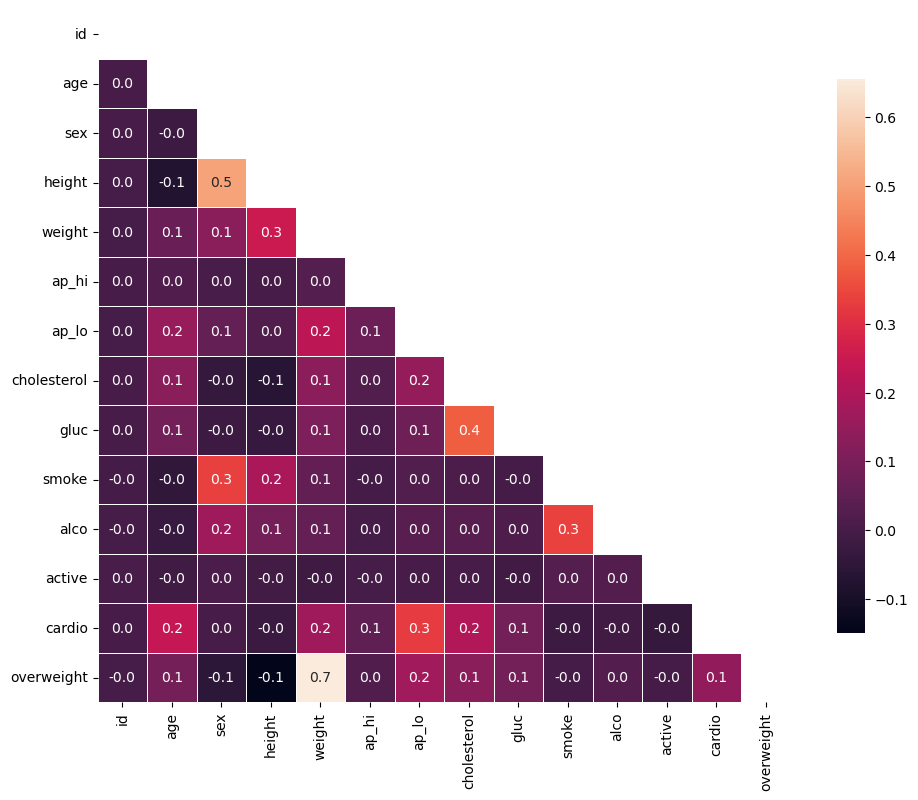

In [49]:
draw_heat_map()